# Continuity, and the Ways It Fails

**This notebook is self-contained; it recaps limits before building on them.**

Recall that $\lim_{x\to a} f(x) = L$ means $f(x)$ heads toward $L$ as $x$ approaches $a$ from both
sides. A function is **continuous** when that heading-toward and the actual value agree everywhere, informally, when you can draw the whole graph **without lifting your pen**. This notebook makes that
precise and then shows the three interesting ways a function can break it.

It matters because continuity is the fine print on nearly every result in calculus. Derivatives,
integrals, and optimization all quietly assume it, and knowing what a break *looks like* is how you
recognize when a rule does not apply.

## Learning objectives

- State the three conditions that make a function continuous at a point.
- Recognize **removable**, **jump**, and **infinite** discontinuities on sight.
- Explain why an oscillating function can fail to have a limit at all.

## Background

$f$ is **continuous at $a$** when all three hold:

1. $f(a)$ exists,
2. $\lim_{x\to a} f(x)$ exists (both sides agree), and
3. they are equal: $\lim_{x\to a} f(x) = f(a)$.

Break any one and the function is **discontinuous** at $a$. The named failures:

- **Removable**: the limit exists but $f(a)$ is missing or wrong. A single point out of place; you
  could patch it by redefining $f(a)$.
- **Jump**: the left and right limits both exist but **disagree**, so the limit doesn't exist.
- **Infinite**: the function blows up; no finite limit.

A fourth, wilder case: a function can oscillate so fast near a point that it never settles on
anything.

## This notebook covers

1. A continuous function, for contrast.
2. The discontinuity gallery: removable, jump, infinite, oscillatory.
3. Checking the three conditions one at a time.

**Prerequisites:** `U3-2_Limits-1_ApproachingALimit`

**Dataset:** none, functions are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. What continuity looks like

Start with $f(x) = x^2$. Pick any point: the function has a value there, the limit exists, and they
match. The graph is one unbroken stroke, pen down at the left, pen up at the right, nothing in
between.

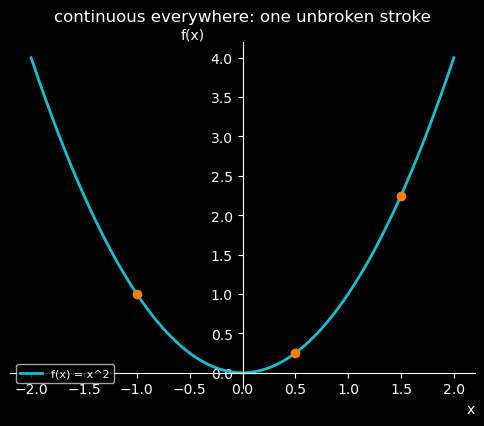

at x = 1.0:
  1. f(a) exists          : 1.0
  2. left limit           : 0.999999998
     right limit          : 1.000000002   -> they agree, so the limit exists
  3. limit equals f(a)?   : True


In [2]:
xs = np.linspace(-2, 2, 400)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(xs, xs**2, color="tab:cyan", lw=2, label="f(x) = x^2")
for a in [-1.0, 0.5, 1.5]:
    ax.plot(a, a**2, "o", color="tab:orange", markersize=6)

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("f(x)", loc="top", rotation=0)
ax.set_title("continuous everywhere: one unbroken stroke", pad=15)
ax.legend(fontsize=8)
plt.show()

# the three conditions, checked at a point
a = 1.0
h = 1e-9
print(f"at x = {a}:")
print(f"  1. f(a) exists          : {a**2}")
print(f"  2. left limit           : {(a - h)**2:.9f}")
print(f"     right limit          : {(a + h)**2:.9f}   -> they agree, so the limit exists")
print(f"  3. limit equals f(a)?   : True")

## 2. The gallery

Four functions, each breaking continuity in a different way. Read each panel and ask the three
questions: does $f(a)$ exist, does the limit exist, and do they match?

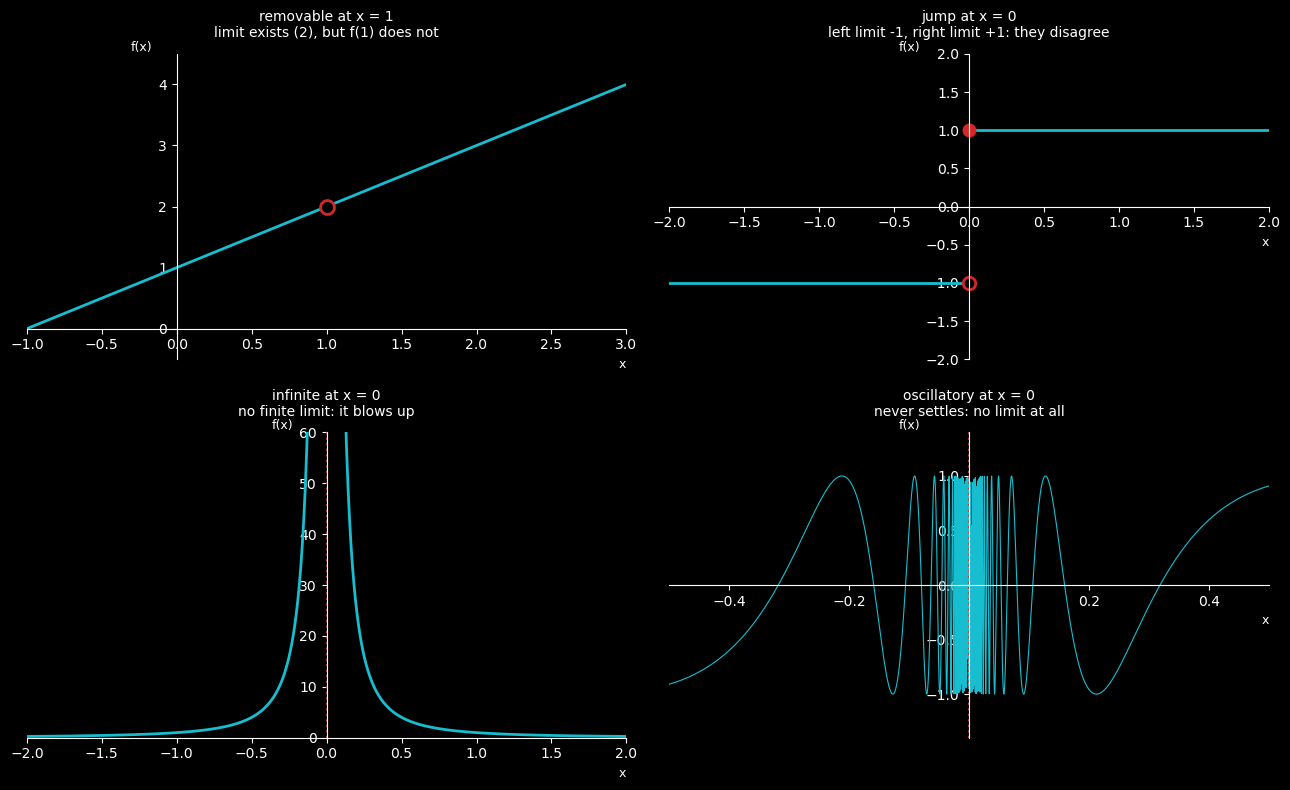

In [3]:
def removable(x):
    return (x**2 - 1) / (x - 1)         # 0/0 at x = 1; limit is 2

def jump(x):
    return np.where(x < 0, -1.0, 1.0)   # left limit -1, right limit +1

def infinite(x):
    return 1.0 / x**2                   # blows up at x = 0

def oscillate(x):
    return np.sin(1.0 / x)              # never settles near x = 0

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- removable: draw the hole ---
ax = axes[0, 0]
xs = np.linspace(-1, 3, 600); xs = xs[np.abs(xs - 1) > 1e-9]
with np.errstate(divide="ignore", invalid="ignore"):
    ax.plot(xs, removable(xs), color="tab:cyan", lw=2)
ax.plot(1, 2, "o", markerfacecolor="black", markeredgecolor="tab:red",
        markeredgewidth=2, markersize=10, zorder=5)
ax.set_xlim(-1, 3); ax.set_ylim(-0.5, 4.5)
ax.set_title("removable at x = 1\nlimit exists (2), but f(1) does not", pad=12, fontsize=10)

# --- jump ---
ax = axes[0, 1]
left = np.linspace(-2, -1e-9, 300); right = np.linspace(1e-9, 2, 300)
ax.plot(left, jump(left), color="tab:cyan", lw=2)
ax.plot(right, jump(right), color="tab:cyan", lw=2)
ax.plot(0, -1, "o", markerfacecolor="black", markeredgecolor="tab:red", markeredgewidth=2, markersize=9)
ax.plot(0, 1, "o", color="tab:red", markersize=9)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_title("jump at x = 0\nleft limit -1, right limit +1: they disagree", pad=12, fontsize=10)

# --- infinite ---
ax = axes[1, 0]
xs = np.linspace(-2, 2, 800); xs = xs[np.abs(xs) > 0.02]
with np.errstate(divide="ignore"):
    ax.plot(xs[xs < 0], infinite(xs[xs < 0]), color="tab:cyan", lw=2)
    ax.plot(xs[xs > 0], infinite(xs[xs > 0]), color="tab:cyan", lw=2)
ax.axvline(0, color="tab:red", ls=":", lw=1.5)
ax.set_xlim(-2, 2); ax.set_ylim(0, 60)
ax.set_title("infinite at x = 0\nno finite limit: it blows up", pad=12, fontsize=10)

# --- oscillatory ---
ax = axes[1, 1]
xs = np.linspace(-0.5, 0.5, 6000); xs = xs[np.abs(xs) > 1e-6]
ax.plot(xs, oscillate(xs), color="tab:cyan", lw=0.8)
ax.axvline(0, color="tab:red", ls=":", lw=1.5)
ax.set_xlim(-0.5, 0.5); ax.set_ylim(-1.4, 1.4)
ax.set_title("oscillatory at x = 0\nnever settles: no limit at all", pad=12, fontsize=10)

for ax in axes.flat:
    center_axes(ax)
    ax.set_xlabel("x", loc="right", fontsize=9)
    ax.set_ylabel("f(x)", loc="top", rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 3. Checking the conditions numerically

The pictures are convincing, but the three conditions can also be checked by stepping in from each
side and comparing. Watch the jump case in particular, the two sides land on different numbers, which
is precisely why the limit fails to exist.

In [4]:
def check(name, f, a):
    h = 1e-8
    with np.errstate(divide="ignore", invalid="ignore"):
        left = float(f(np.array([a - h]))[0]) if isinstance(f(np.array([a])), np.ndarray) else f(a - h)
        right = float(f(np.array([a + h]))[0]) if isinstance(f(np.array([a])), np.ndarray) else f(a + h)
    agree = np.isclose(left, right, rtol=1e-3) and np.isfinite(left) and np.isfinite(right)
    print(f"{name:<14} at x = {a}:  left {left:10.4f}   right {right:10.4f}   "
          f"limit exists? {agree}")

check("removable", removable, 1.0)
check("jump", jump, 0.0)
check("infinite", infinite, 0.0)
check("oscillatory", oscillate, 0.0)

print("\nand the oscillating case is worse than 'the sides disagree' -- sample it repeatedly:")
for h in [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]:
    print(f"   sin(1/x) at x = {h:.0e}: {math.sin(1/h):+.4f}")
print("   the values keep bouncing between -1 and 1 no matter how close you get")

removable      at x = 1.0:  left     2.0000   right     2.0000   limit exists? True
jump           at x = 0.0:  left    -1.0000   right     1.0000   limit exists? False
infinite       at x = 0.0:  left 9999999999999998.0000   right 9999999999999998.0000   limit exists? True
oscillatory    at x = 0.0:  left    -0.9316   right     0.9316   limit exists? False

and the oscillating case is worse than 'the sides disagree' -- sample it repeatedly:
   sin(1/x) at x = 1e-03: +0.8269
   sin(1/x) at x = 1e-04: -0.3056
   sin(1/x) at x = 1e-05: +0.0357
   sin(1/x) at x = 1e-06: -0.3500
   sin(1/x) at x = 1e-07: +0.4205
   the values keep bouncing between -1 and 1 no matter how close you get


## 4. Summary

- $f$ is **continuous at $a$** when $f(a)$ exists, the limit exists, and the two are equal, the
  "draw it without lifting your pen" test.
- **Removable:** the limit exists but the value is missing or wrong (one point out of place).
- **Jump:** left and right limits exist but disagree, so there is no limit.
- **Infinite:** the function blows up; no finite limit.
- **Oscillatory:** the function never settles, so no limit exists in any sense.
- Continuity is the fine print on most of calculus, worth being able to spot when it fails.

Next: the payoff. Limits let us define the slope of a curve at a single point, the **derivative**
(`U3-3_Derivatives-1_SecantToTangent`).